In [35]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../../data/project2/california_housing.csv')
print(df.head())
print(df.describe())
print(df.info())
print(df.isnull().sum())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
          longitude      latitude  housing_median_age   total_rooms  \
coun

In [3]:
# Integer encode proximity due to the somewhat linear nature of its relationship to house price
print(df['ocean_proximity'].unique())

proximity_mapping = {
    'ISLAND':     4,
    'NEAR OCEAN': 3,
    'NEAR BAY':   2,
    '<1H OCEAN':  1,
    'INLAND':     0,

}

df['ocean_proximity'] = df['ocean_proximity'].map(proximity_mapping)
print(df.head())
print(df['ocean_proximity'].unique())

['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  ocean_proximity  
0       322.0       126.0         8.3252            452600.0                2  
1      2401.0      1138.0         8.3014            358500.0                2  
2       496.0       177.0         7.2574            352100.0                2  
3       558.0       219.0         5.6431            341300.0                2  
4       565.0       259.0         3.8462            342200.0                2  
[2 1 0 3 4]


C:\Users\jesse\AppData\Local\Temp\ipykernel_10920\3832813655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', palette='viridis')


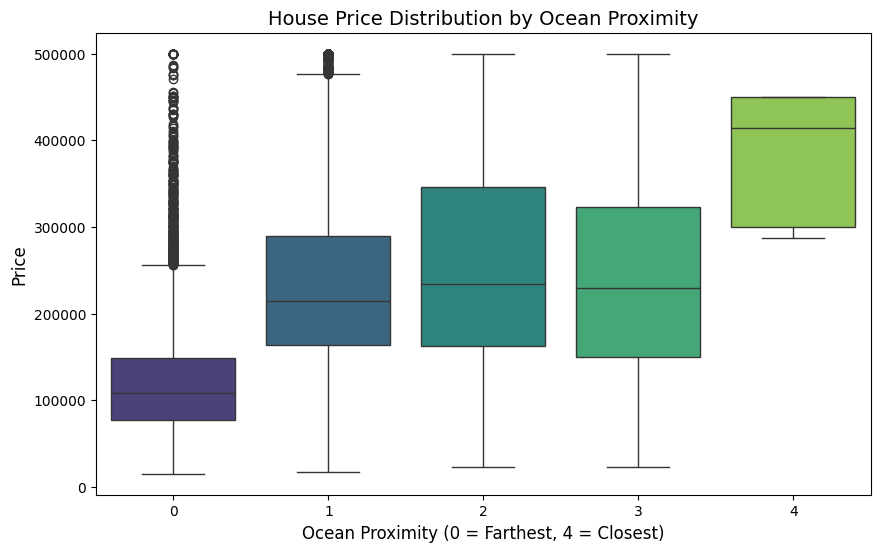

C:\Users\jesse\AppData\Local\Temp\ipykernel_10920\3832813655.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='ocean_proximity', y='median_house_value', alpha=0.5, palette='viridis', jitter=True)


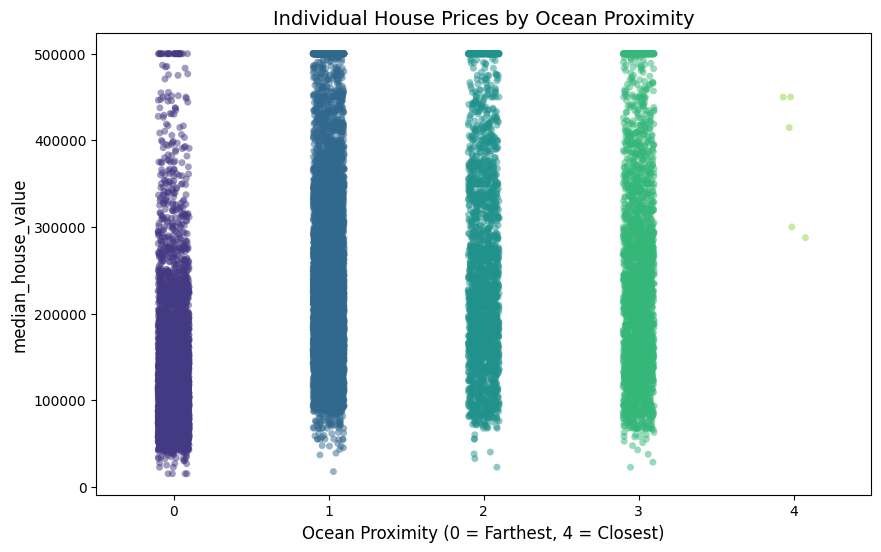

In [10]:
# Visualize price vs distance to verify rough linear relation
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', palette='viridis')

plt.title('House Price Distribution by Ocean Proximity', fontsize=14)
plt.xlabel('Ocean Proximity (0 = Farthest, 4 = Closest)', fontsize=12)
plt.ylabel('Price', fontsize=12)

# Show the plot
plt.show()

plt.figure(figsize=(10, 6))
# 'jitter=True' spreads points out horizontally so they don't overlap completely
sns.stripplot(data=df, x='ocean_proximity', y='median_house_value', alpha=0.5, palette='viridis', jitter=True)

plt.title('Individual House Prices by Ocean Proximity', fontsize=14)
plt.xlabel('Ocean Proximity (0 = Farthest, 4 = Closest)', fontsize=12)
plt.ylabel('median_house_value', fontsize=12)

# Show the plot
plt.show()

In [5]:
# Drop NA columns since low % have a null value. We could impute, but not worth tainting data for only ~1% more data
df_cleaned = df.dropna()
print(df_cleaned.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


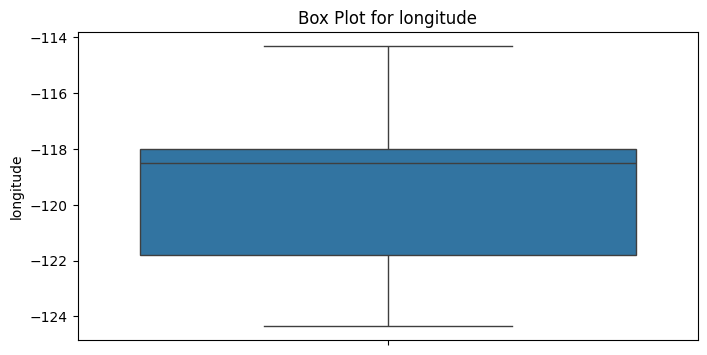

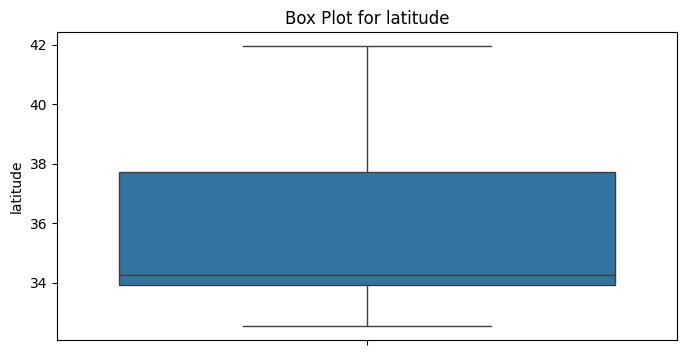

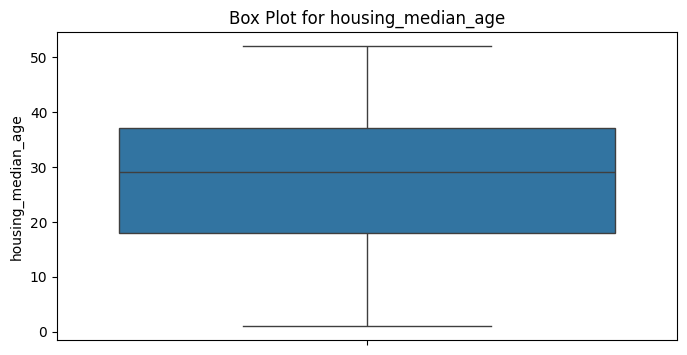

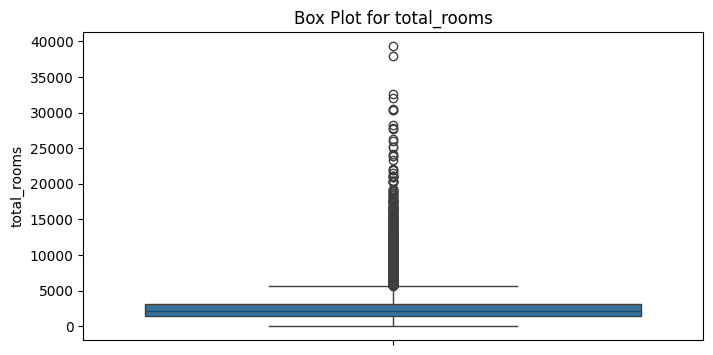

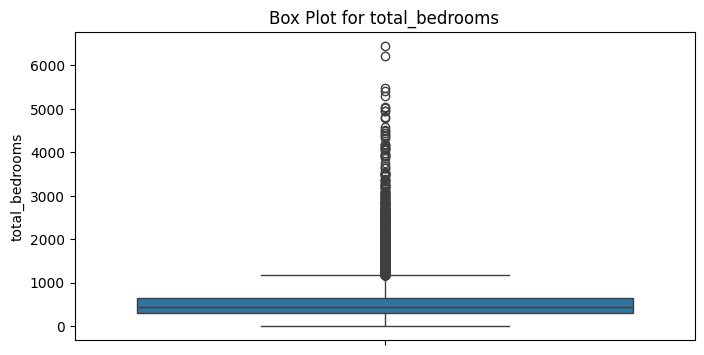

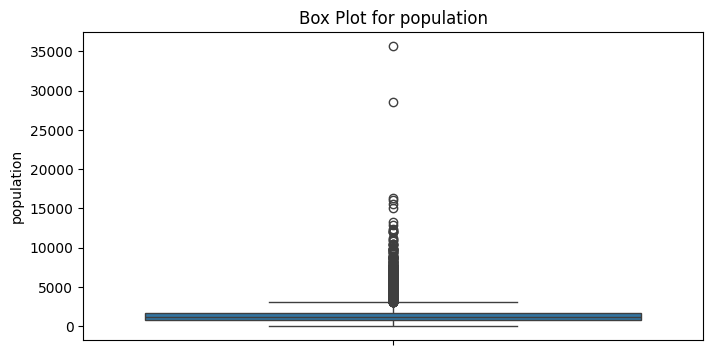

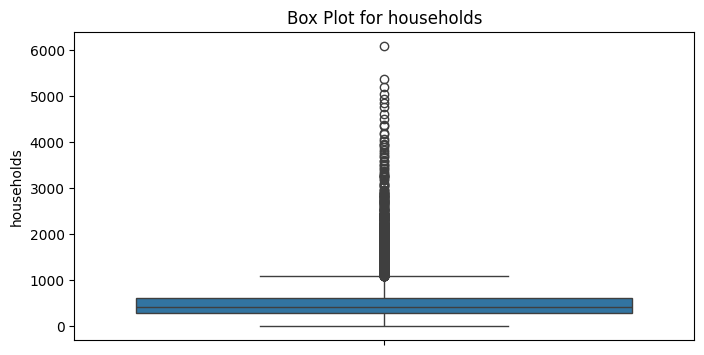

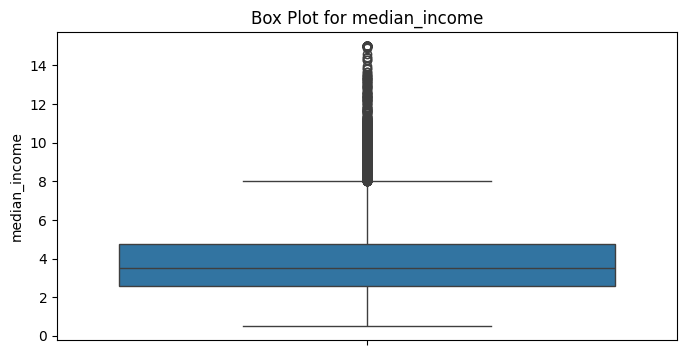

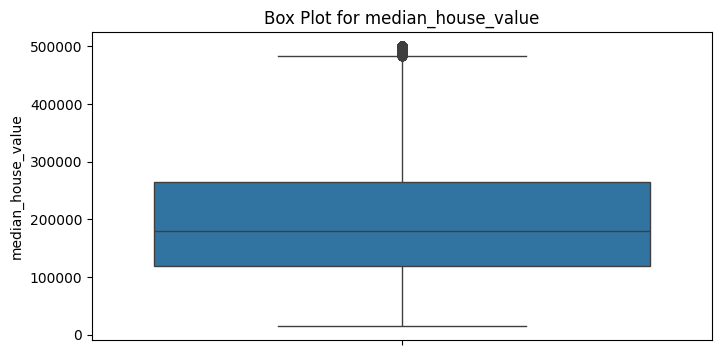

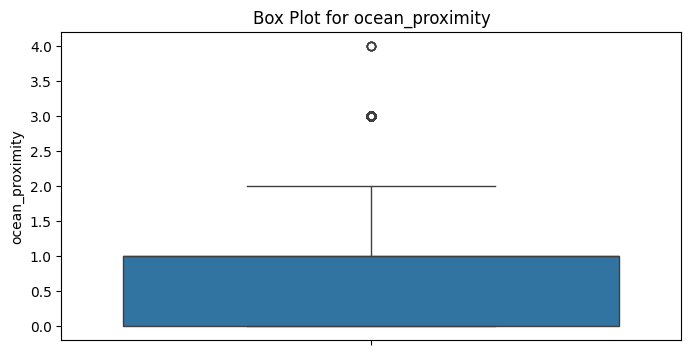

In [11]:
# Inspect for outliers. Not dropping for now, but will revisit this in the future.
for col in df.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot for {col}')
    plt.show()

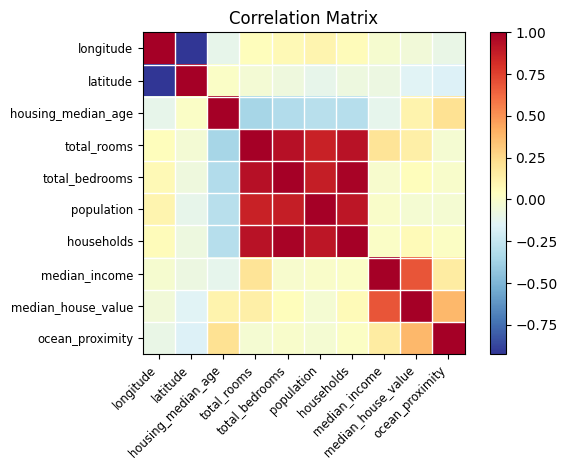

In [6]:
corr_matrix = df_cleaned.corr()
sm.graphics.plot_corr(corr_matrix, xnames=corr_matrix.columns)
plt.show()

<Figure size 600x400 with 0 Axes>

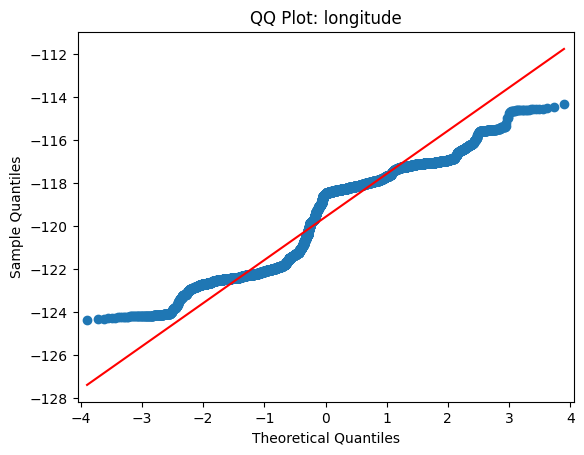

<Figure size 600x400 with 0 Axes>

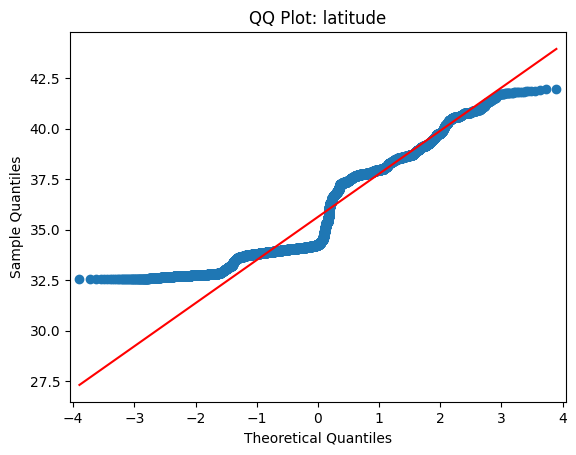

<Figure size 600x400 with 0 Axes>

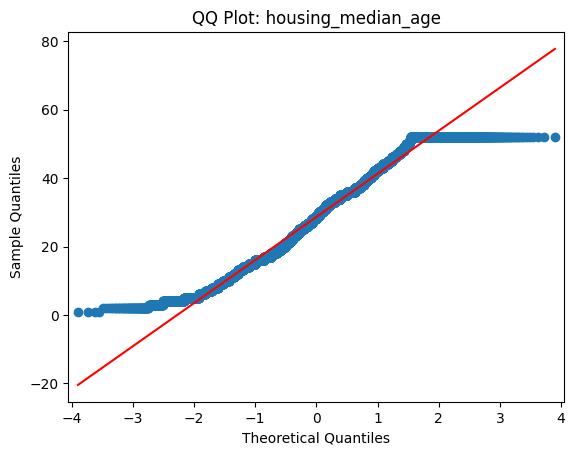

<Figure size 600x400 with 0 Axes>

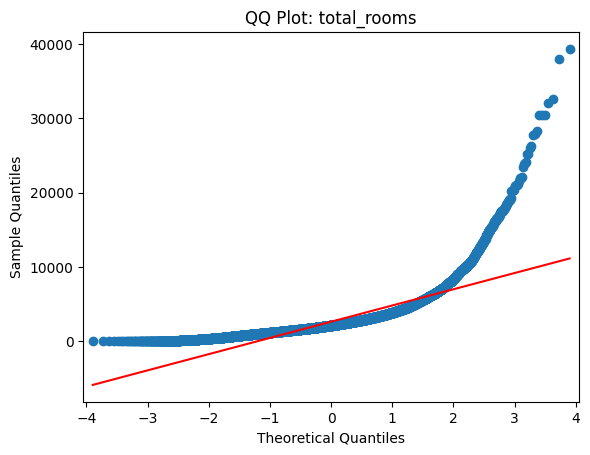

<Figure size 600x400 with 0 Axes>

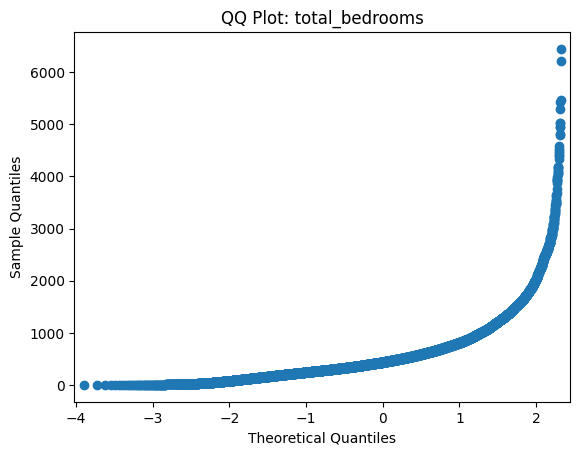

<Figure size 600x400 with 0 Axes>

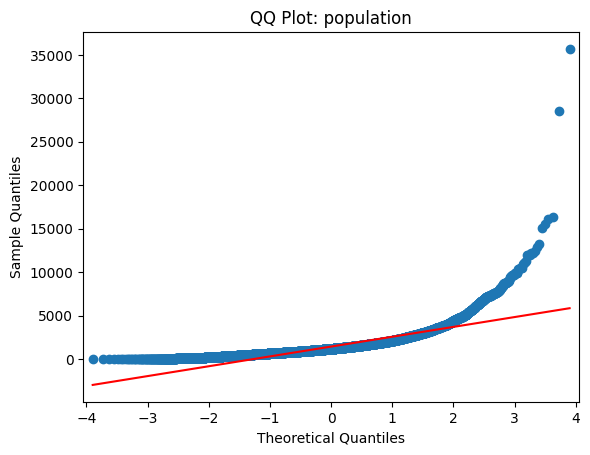

<Figure size 600x400 with 0 Axes>

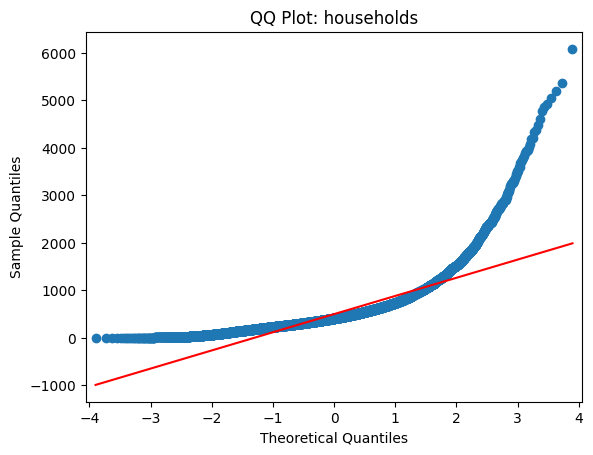

<Figure size 600x400 with 0 Axes>

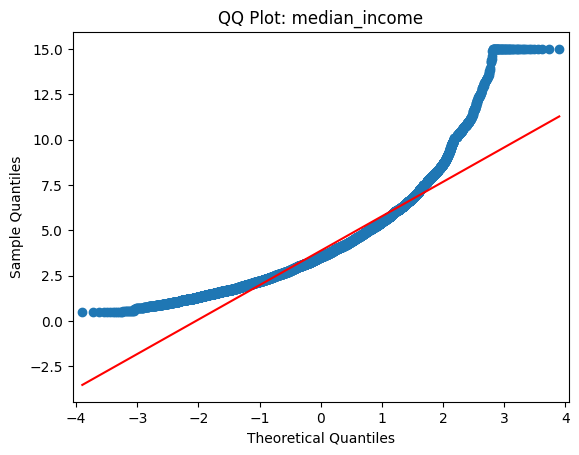

<Figure size 600x400 with 0 Axes>

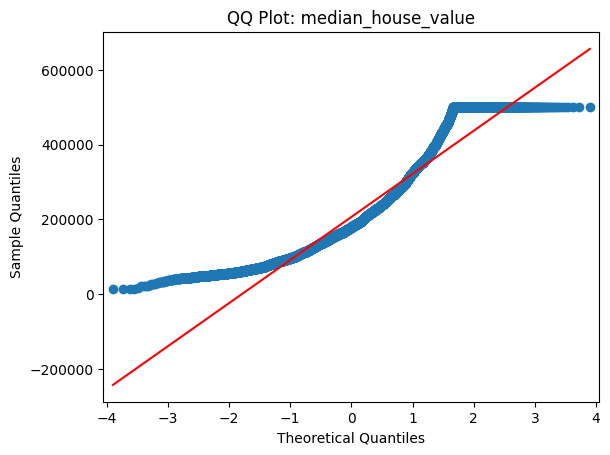

<Figure size 600x400 with 0 Axes>

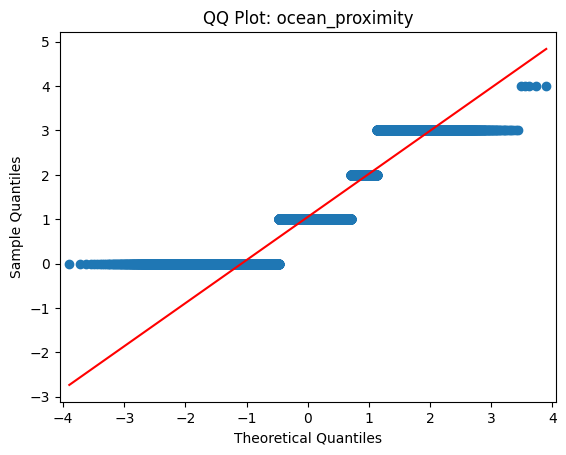

In [7]:
# no NaN are present so we dont need to handle this
for col in df_cleaned.columns:
    plt.figure(figsize=(6, 4))

    sm.qqplot(df[col], line='s')

    plt.title(f'QQ Plot: {col}')
    plt.show()

In [8]:
output_path = '../../../data/project2/california_housing_cleaned.csv'
df_cleaned.to_csv(output_path, index=False)